In [1]:
from planning.planner import connect_poses_with_curvature, pose_to_node, node_to_pose, plan_from_path, a_star, create_graph, add_edges
from planning.timed_env import TimedEnv
import networkx as nx
import matplotlib.pyplot as plt
from aido_schemas import Context, FriendlyPose
from dt_protocols import PlanningSetup, Rectangle, Circle, PlacedPrimitive, Appearance
import math
import numpy as np

ps = PlanningSetup(
    environment=[
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=0.1, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=4.9, ymin=0.0, xmax=5.0, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=4.9, xmax=5.0, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=5.0, ymax=0.1),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.539619150260162, y=2.764151352098707, theta_deg=200.25092590378074),
            primitive=Circle(radius=0.4955915626161882),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.028568920007228, y=2.285092439438581, theta_deg=178.09485615456518),
            primitive=Circle(radius=0.7575022270458687),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.6254208399349936, y=0.21987096862042532, theta_deg=320.4926048628041),
            primitive=Circle(radius=0.6675524439185758),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.125671199410717, y=4.170206386803661, theta_deg=175.58822051345493),
            primitive=Circle(radius=0.5670801581108957),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.51392445095758, y=3.9871575410872353, theta_deg=206.0268476129309),
            primitive=Circle(radius=0.45107485977504896),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.6731420817120276, y=3.9482933242598985, theta_deg=42.59271886758431),
            primitive=Circle(radius=0.6283525898487949),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.3740911457165907, y=3.1708367703589997, theta_deg=349.73363772371755),
            primitive=Circle(radius=0.34614476347426265),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=2.9854067191328992, y=2.204884814489365, theta_deg=224.0830942194504),
            primitive=Rectangle(
                xmin=-0.3451722951775122, ymin=-0.22614183237669566,
                xmax=0.3451722951775122, ymax=0.22614183237669566
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.2676078081257216, y=2.5452693717253356, theta_deg=326.80660552685725),
            primitive=Rectangle(
                xmin=-0.3024006603443898, ymin=-0.32153226185970135,
                xmax=0.3024006603443898, ymax=0.32153226185970135
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.2234594147202889, y=2.8629082010227744, theta_deg=331.0065395116919),
            primitive=Rectangle(
                xmin=-0.2503264595125117, ymin=-0.3295076552525854,
                xmax=0.2503264595125117, ymax=0.3295076552525854
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.35700000513042396, y=0.4306467698119637, theta_deg=49.52091657795261),
            primitive=Rectangle(
                xmin=-0.25126489066548285, ymin=-0.23991484191677537,
                xmax=0.25126489066548285, ymax=0.23991484191677537
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.8050801066863106, y=2.090759274161887, theta_deg=155.73643133572406),
            primitive=Rectangle(
                xmin=-0.31161477269728577, ymin=-0.3700610259863343,
                xmax=0.31161477269728577, ymax=0.3700610259863343
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.786671021694601, y=0.12334100795562519, theta_deg=127.87379050822763),
            primitive=Rectangle(
                xmin=-0.213766825486308, ymin=-0.23112790550116707,
                xmax=0.213766825486308, ymax=0.23112790550116707
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=2.1969914039975658, y=0.57650745756812, theta_deg=143.55133291933856),
            primitive=Rectangle(
                xmin=-0.35460471946640426, ymin=-0.22756394716538508,
                xmax=0.35460471946640426, ymax=0.22756394716538508
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
    ],
    body=[
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=-0.13, ymin=-0.045, xmax=0.07, ymax=0.045),
            appearance=Appearance(fillcolor="blue", rel_zorder=1),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=-0.03, ymin=-0.065, xmax=0.03, ymax=0.065),
            appearance=Appearance(fillcolor="black", rel_zorder=-1),
        ),
    ],
    bounds=Rectangle(xmin=0.0, ymin=0.0, xmax=5.0, ymax=5.0),
    max_linear_velocity_m_s=0.4,
    min_linear_velocity_m_s=-0.3,
    max_angular_velocity_deg_s=30.0,
    max_curvature=float("inf"),
    tolerance_xy_m=0.05,
    tolerance_theta_deg=20.0,
)

t_env = TimedEnv(ps.environment, 0.3)

DEBUG:commons:version: 6.2.4 *
DEBUG:typing:version: 6.2.3
DEBUG:aido_schemas:aido-protocols version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:nodes:version 6.2.17 path /usr/local/lib/python3.8/dist-packages pyparsing 2.4.6
DEBUG:dt_protocols:dt-protocols version 6.2.35 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_world:duckietown-world version 6.4.3 path /usr/local/lib/python3.8/dist-packages
DEBUG:geometry:PyGeometry-z6 version 2.1.4 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_challenges:duckietown_challenges version 6.5.2 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_build_utils:duckietown_build_utils version 6.2.78 path /usr/local/lib/python3.8/dist-packages
DEBUG:duckietown_docker_utils:duckietown_docker_utils version 6.1.1 path /usr/local/lib/python3.8/dist-packages
DEBUG:ipce:version 6.1.2 path /usr/local/lib/python3.8/dist-packages


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_plan(start_pose, plan):
    """
    Simulate the trajectory given a start pose (FriendlyPose) and a plan (list of PlanStep).
    Returns arrays of x, y, theta.
    """
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg
    xs, ys, thetas = [x], [y], [theta_deg]
    for step in plan:
        duration = step.duration
        v = step.velocity_x_m_s
        w_deg = step.angular_velocity_deg_s
        w = np.deg2rad(w_deg)
        theta = np.deg2rad(theta_deg)
        dt = 0.001
        n = max(1, int(duration / dt))
        for _ in range(n):
            if abs(w) < 1e-6:
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
            else:
                x += v * np.cos(theta) * dt
                y += v * np.sin(theta) * dt
                theta += w * dt
            xs.append(x)
            ys.append(y)
            thetas.append(np.rad2deg(theta))
        theta_deg = np.rad2deg(theta)
    return np.array(xs), np.array(ys), np.array(thetas)

def plot_trajectory_from_path(plan, path, planning_setup=None):
    """
    Plots the continuous trajectory defined by the plans on the edges of the path.
    The line is blue if the vehicle moves forward, green if it moves backward.
    If planning_setup is provided, also plots the environment.
    """

    def draw_primitive(ax, placed_primitive):
        pose = placed_primitive.pose
        primitive = placed_primitive.primitive
        appearance = getattr(placed_primitive, "appearance", None)
        color = getattr(appearance, "fillcolor", "gray") if appearance else "gray"
        if isinstance(primitive, Rectangle):
            # Rectangle is defined in local frame, so we need to transform corners
            corners = np.array([
                [primitive.xmin, primitive.ymin],
                [primitive.xmax, primitive.ymin],
                [primitive.xmax, primitive.ymax],
                [primitive.xmin, primitive.ymax],
                [primitive.xmin, primitive.ymin],
            ])
            # Rotation
            theta = np.deg2rad(pose.theta_deg)
            R = np.array([[np.cos(theta), -np.sin(theta)],
                          [np.sin(theta),  np.cos(theta)]])
            rotated = (R @ corners.T).T
            # Translation
            translated = rotated + np.array([pose.x, pose.y])
            ax.plot(translated[:,0], translated[:,1], color=color, linewidth=0)
            ax.fill(translated[:,0], translated[:,1], color=color, alpha=0.8)
        elif isinstance(primitive, Circle):
            circle = plt.Circle((pose.x, pose.y), primitive.radius, color=color, alpha=0.8, linewidth=0)
            ax.add_patch(circle)

    start_node = path[0]
    start_pose = node_to_pose(start_node)
    x, y, theta_deg = start_pose.x, start_pose.y, start_pose.theta_deg

    fig, ax = plt.subplots(figsize=(6,6))
    xs_all, ys_all = [x], [y]  # For start/goal markers

    # Draw environment if provided
    if planning_setup is not None:
        for placed_primitive in getattr(planning_setup, "environment", []):
            draw_primitive(ax, placed_primitive)

    for step in plan:
        # Simulate this step only
        temp_pose = type(start_pose)(x, y, theta_deg)
        xs, ys, thetas = simulate_plan(temp_pose, [step])
        # Only plot the segment (not the repeated start)
        color = 'blue' if step.velocity_x_m_s > 0 else 'green'
        ax.plot(xs, ys, color=color)
        # Update for next step
        x, y, theta_deg = xs[-1], ys[-1], thetas[-1]
        xs_all.extend(xs[1:])  # skip the first point to avoid duplicates
        ys_all.extend(ys[1:])

    ax.scatter([xs_all[0], xs_all[-1]], [ys_all[0], ys_all[-1]], c='red', label="Start/Goal")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title("Planned Trajectory (from edge plans)")
    ax.axis('equal')
    ax.grid(True)
    ax.legend()
    plt.show()

/code/planning/packages/planning/planner.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 147 nodes visited


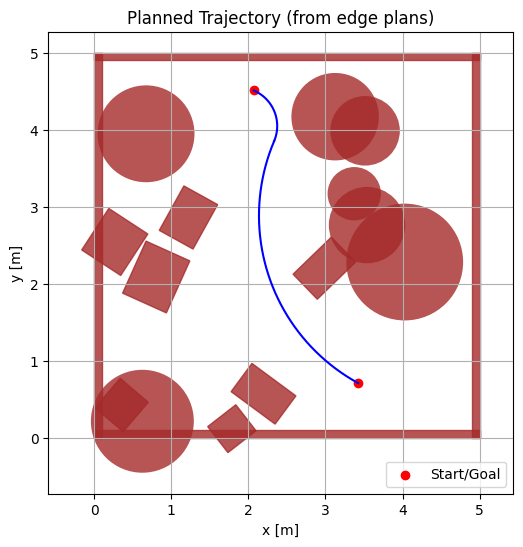

[(207, 451, 337), (233, 385, 247), (342, 71, 331.28722809483247), (342, 71, 142)]
[PlanStep(duration=3.0, velocity_x_m_s=0.2617993877991495, angular_velocity_deg_s=-30.0), PlanStep(duration=9.108948550098393, velocity_x_m_s=0.4, angular_velocity_deg_s=9.25323352429321), PlanStep(duration=5.690425730172251, velocity_x_m_s=0.0, angular_velocity_deg_s=30.0)]
17.799374280270644


In [3]:
# A star
start = FriendlyPose(2.0667262838450213, 4.514478476178308, 337.1563223638467)
goal = FriendlyPose(3.4199032893600485, 0.7103381954156884, 142.31580213952952)

plan, path = a_star(ps, start, goal, t_env)

if plan is not None:
    plot_trajectory_from_path(plan, path, ps)

print(path)
print(plan)
print(sum([step.duration for step in plan]))

In [4]:
ps = PlanningSetup(
    environment=[
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=0.1, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=4.9, ymin=0.0, xmax=5.0, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=4.9, xmax=5.0, ymax=5.0),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=5.0, ymax=0.1),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.3320344629244723, y=2.969040466277155, theta_deg=283.0587791549231),
            primitive=Circle(radius=0.5079918904613967),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=2.316265682647489, y=0.7695884749392695, theta_deg=127.95193423773836),
            primitive=Circle(radius=0.3796863128330219),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.7747957246442658, y=2.924794692664637, theta_deg=73.38397646942201),
            primitive=Circle(radius=0.6329421744859169),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.000055316602008, y=2.035137596769765, theta_deg=324.79595069162326),
            primitive=Circle(radius=0.4631460789492661),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.092784601410142, y=3.6661764366014364, theta_deg=40.32099899009148),
            primitive=Circle(radius=0.6171501144026188),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.6040582625229867, y=1.9160580136177545, theta_deg=93.04693012027086),
            primitive=Circle(radius=0.471034810982069),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.3222880393934144, y=0.7343894750337748, theta_deg=81.14920714352239),
            primitive=Circle(radius=0.43837410815478856),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.190065692917714, y=2.9104702924356984, theta_deg=62.96727606023075),
            primitive=Rectangle(
                xmin=-0.392454374453931, ymin=-0.2488900251444788,
                xmax=0.392454374453931, ymax=0.2488900251444788
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.5906587933287115, y=3.863608944518277, theta_deg=322.5777140456887),
            primitive=Rectangle(
                xmin=-0.2719013220968321, ymin=-0.21299046071512798,
                xmax=0.2719013220968321, ymax=0.21299046071512798
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.862062977431788, y=1.2939414454842946, theta_deg=278.7545515590535),
            primitive=Rectangle(
                xmin=-0.235064511685386, ymin=-0.366282968986559,
                xmax=0.235064511685386, ymax=0.366282968986559
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.3962008981520513, y=0.313630857856973, theta_deg=91.12192561575047),
            primitive=Rectangle(
                xmin=-0.2477431497914869, ymin=-0.281049924560643,
                xmax=0.2477431497914869, ymax=0.281049924560643
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.7904496576486695, y=1.406814500764633, theta_deg=253.89770359922846),
            primitive=Rectangle(
                xmin=-0.20121809728306858, ymin=-0.29862813625071544,
                xmax=0.20121809728306858, ymax=0.29862813625071544
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.5251784031002, y=1.3248480094618265, theta_deg=340.1201678364475),
            primitive=Rectangle(
                xmin=-0.39238238454527885, ymin=-0.22429293232378877,
                xmax=0.39238238454527885, ymax=0.22429293232378877
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.6409945175525977, y=3.542023647515044, theta_deg=128.1492799734227),
            primitive=Rectangle(
                xmin=-0.23928243741093067, ymin=-0.36378645394385123,
                xmax=0.23928243741093067, ymax=0.36378645394385123
            ),
            appearance=Appearance(fillcolor="brown"),
        ),
    ],
    body=[
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=-0.13, ymin=-0.045, xmax=0.07, ymax=0.045),
            appearance=Appearance(fillcolor="blue", rel_zorder=1),
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=-0.03, ymin=-0.065, xmax=0.03, ymax=0.065),
            appearance=Appearance(fillcolor="black", rel_zorder=-1),
        ),
    ],
    bounds=Rectangle(xmin=0.0, ymin=0.0, xmax=5.0, ymax=5.0),
    max_linear_velocity_m_s=0.4,
    min_linear_velocity_m_s=-0.3,
    max_angular_velocity_deg_s=30.0,
    max_curvature=float("inf"),
    tolerance_xy_m=0.05,
    tolerance_theta_deg=20.0,
)

t_env = TimedEnv(ps.environment, 0.3)

/code/planning/packages/planning/planner.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 149 nodes visited


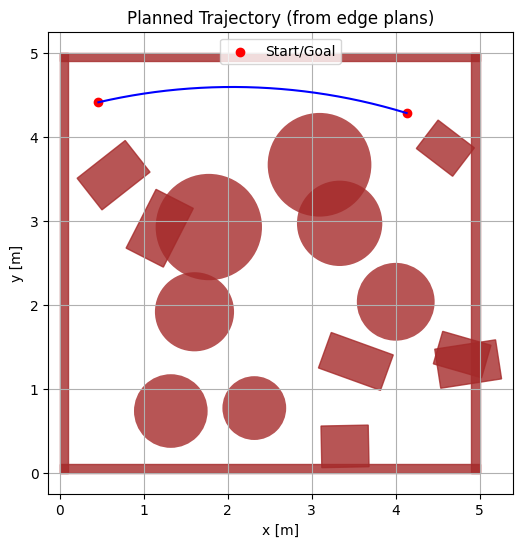

[(46, 441, 57), (46, 441, 13), (413, 428, 342.9425948860934), (413, 428, 13)]
[PlanStep(duration=1.4666666666666666, velocity_x_m_s=0.0, angular_velocity_deg_s=-30.0), PlanStep(duration=9.2868804225977, velocity_x_m_s=0.4, angular_velocity_deg_s=-3.2365448617996755), PlanStep(duration=1.0019135037968872, velocity_x_m_s=0.0, angular_velocity_deg_s=30.0)]
11.755460593061255


In [5]:
start = FriendlyPose(x=0.4550161520465029, y=4.414647296152004, theta_deg=56.679148709124625)
goal = FriendlyPose(x=4.132906067214372, y=4.278560350987158, theta_deg=13.191124692441898)

plan, path = a_star(ps, start, goal, t_env)

if plan is not None:
    plot_trajectory_from_path(plan, path, ps)

print(path)
print(plan)
print(sum([step.duration for step in plan]))

In [6]:
ps = PlanningSetup(
    environment=[
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=0.1, ymax=5.0),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=4.9, ymin=0.0, xmax=5.0, ymax=5.0),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=4.9, xmax=5.0, ymax=5.0),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=0.0, ymin=0.0, xmax=5.0, ymax=0.1),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.4678305826219633, y=3.1712221248611216, theta_deg=284.2428697939877),
            primitive=Circle(radius=0.5978861638040704),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=2.9974366714760654, y=0.37218337933483614, theta_deg=303.21725625008986),
            primitive=Circle(radius=0.6739955663880008),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=1.8857436533752103, y=4.01118936247755, theta_deg=217.9657282143734),
            primitive=Circle(radius=0.39173019400876063),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.6715255619025512, y=1.2448063317356717, theta_deg=168.231575160358),
            primitive=Circle(radius=0.6816238442775071),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.6236145253945162, y=1.4101996331185633, theta_deg=332.5813347570572),
            primitive=Circle(radius=0.45774691626373143),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.374783661268914, y=4.973321092341977, theta_deg=122.00627550557564),
            primitive=Circle(radius=0.4607468228642017),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.421639907878216, y=3.256805130456045, theta_deg=55.65554433613155),
            primitive=Circle(radius=0.7846068696580473),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.292873211581124, y=3.050158952538626, theta_deg=249.44300792132432),
            primitive=Rectangle(xmin=-0.30070250722780695, ymin=-0.3446136091895774, xmax=0.30070250722780695, ymax=0.3446136091895774),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=2.9620652238632186, y=0.28391749792478327, theta_deg=197.6540069926583),
            primitive=Rectangle(xmin=-0.33174420476306016, ymin=-0.35638944921866134, xmax=0.33174420476306016, ymax=0.35638944921866134),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.802894856035514, y=0.9018920122331892, theta_deg=236.58981961997236),
            primitive=Rectangle(xmin=-0.22049945224623163, ymin=-0.25933346662797996, xmax=0.22049945224623163, ymax=0.25933346662797996),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.356331052325245, y=3.8109324264164277, theta_deg=268.15672776967244),
            primitive=Rectangle(xmin=-0.26647856934809716, ymin=-0.20670249897469653, xmax=0.26647856934809716, ymax=0.20670249897469653),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.8653895560443792, y=4.736279221572221, theta_deg=233.51398540674757),
            primitive=Rectangle(xmin=-0.31111156609625473, ymin=-0.29634137669680355, xmax=0.31111156609625473, ymax=0.29634137669680355),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=4.844569656997872, y=2.9788077284135523, theta_deg=278.4261862805697),
            primitive=Rectangle(xmin=-0.22331974202052435, ymin=-0.3490412885104921, xmax=0.22331974202052435, ymax=0.3490412885104921),
            appearance=Appearance(fillcolor="brown")
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=3.019688221654681, y=4.948266381820909, theta_deg=89.16032060326978),
            primitive=Rectangle(xmin=-0.22185903954720157, ymin=-0.3529999068464879, xmax=0.22185903954720157, ymax=0.3529999068464879),
            appearance=Appearance(fillcolor="brown")
        ),
    ],
    body=[
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=-0.13, ymin=-0.045, xmax=0.07, ymax=0.045),
            appearance=Appearance(fillcolor="blue", rel_zorder=1)
        ),
        PlacedPrimitive(
            pose=FriendlyPose(x=0.0, y=0.0, theta_deg=0.0),
            primitive=Rectangle(xmin=-0.03, ymin=-0.065, xmax=0.03, ymax=0.065),
            appearance=Appearance(fillcolor="black", rel_zorder=-1)
        ),
    ],
    bounds=Rectangle(xmin=0.0, ymin=0.0, xmax=5.0, ymax=5.0),
    max_linear_velocity_m_s=0.4,
    min_linear_velocity_m_s=-0.3,
    max_angular_velocity_deg_s=30.0,
    max_curvature=float('inf'),
    tolerance_xy_m=0.05,
    tolerance_theta_deg=20.0,
)

t_env = TimedEnv(ps.environment, 0.3)

/code/planning/packages/planning/planner.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 48 nodes visited


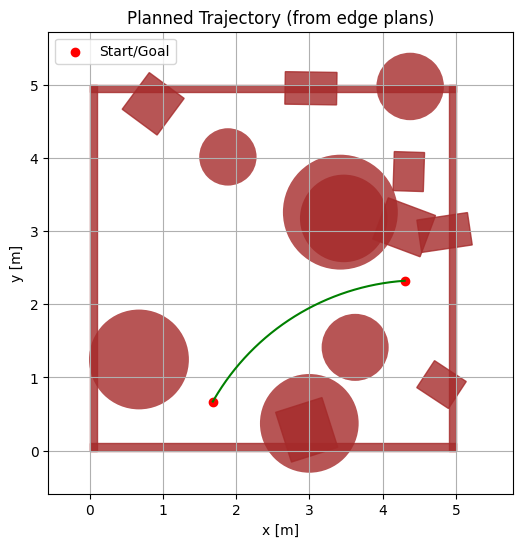

[(430, 232, 4), (168, 67, 60.40306737936021), (168, 67, 209)]
[PlanStep(duration=10.749735741591174, velocity_x_m_s=-0.3, angular_velocity_deg_s=5.246925946387166), PlanStep(duration=4.95323108735466, velocity_x_m_s=0.0, angular_velocity_deg_s=30.0)]
15.702966828945833


In [7]:
start = FriendlyPose(x=4.304263922095645, y=2.317732302735669, theta_deg=4.05371427052454)
goal = FriendlyPose(x=1.6776658309956993, y=0.6678342974920293, theta_deg=208.5172355576972)

plan, path = a_star(ps, start, goal, t_env)

if plan is not None:
    plot_trajectory_from_path(plan, path, ps)

print(path)
print(plan)
print(sum([step.duration for step in plan]))

/code/planning/packages/planning/planner.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 287 nodes visited


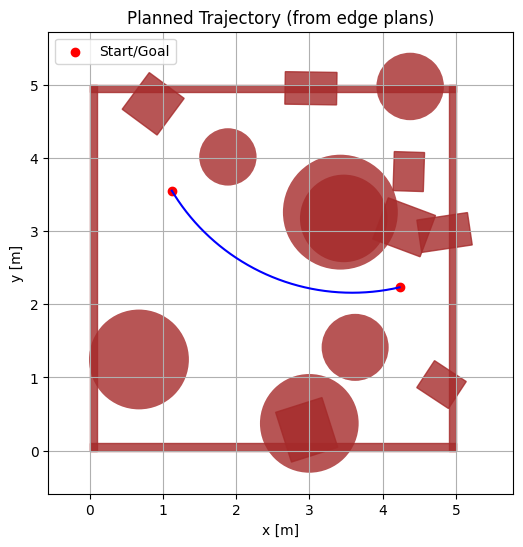

[(423, 223, 130), (423, 223, 193), (112, 355, 121.0036428456803), (112, 355, 193)]
[PlanStep(duration=2.1, velocity_x_m_s=0.0, angular_velocity_deg_s=30.0), PlanStep(duration=9.028730032368092, velocity_x_m_s=0.4, angular_velocity_deg_s=-7.974139983830727), PlanStep(duration=2.3998785718106563, velocity_x_m_s=0.0, angular_velocity_deg_s=30.0)]


In [8]:
start = FriendlyPose(x=4.23191366663338, y=2.2349591340498276, theta_deg=129.79646833966052)
goal = FriendlyPose(x=1.120540580029326, y=3.553347360725483, theta_deg=192.98824990002927)

plan, path = a_star(ps, start, goal, t_env)

if plan is not None:
    plot_trajectory_from_path(plan, path, ps)

print(path)
print(plan)

/code/planning/packages/planning/planner.py:106: RuntimeWarning: divide by zero encountered in scalar divide
  if abs(theta / duration) > ps.max_angular_velocity_deg_s:


A star finished, 48 nodes visited


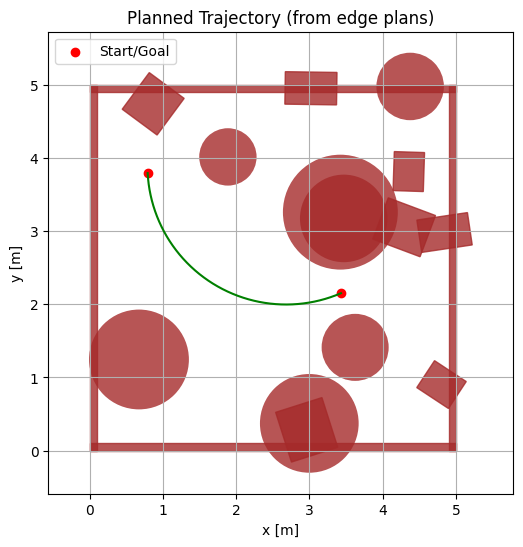

[(79, 379, 93), (343, 215, 203.30189736188942), (343, 215, 311)]
[PlanStep(duration=12.15111821963318, velocity_x_m_s=-0.3, angular_velocity_deg_s=9.077510017445885), PlanStep(duration=3.589936754603686, velocity_x_m_s=0.0, angular_velocity_deg_s=30.0)]


In [9]:
start = FriendlyPose(x=0.7915607828741078, y=3.792455289637093, theta_deg=92.94084832188429)
goal = FriendlyPose(x=3.428455417870997, y=2.1460479602523126, theta_deg=310.7559510822572)

plan, path = a_star(ps, start, goal, t_env)

if plan is not None:
    plot_trajectory_from_path(plan, path, ps)

print(path)
print(plan)